# Импорты

In [68]:
# %pip install matplotlib
# %pip install pymatgen
# %pip install crystal_toolkit

In [69]:
import matplotlib.pyplot as plt
import pandas as pd

In [70]:
from pymatgen.core import Structure

from pymatgen.io.vasp.outputs import Outcar
from pymatgen.io.vasp.outputs import Vasprun
from pymatgen.io.vasp import Incar
from pymatgen.io.vasp.outputs import Chgcar
from pymatgen.io.vasp.outputs import Locpot

from pymatgen.symmetry.bandstructure import HighSymmKpath
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

from pymatgen.electronic_structure.core import Spin

In [71]:
import warnings

In [72]:
# Лицензия VASP прямо запрещает свободное распространение POTCAR-файлов
warnings.filterwarnings(
    "ignore",
    message="No POTCAR file with matching TITEL fields was found"
)

In [73]:
# VASP_run_04
Ni3Al_04_start_structure = Structure.from_file("Ni3Al/POSCAR")
Ni3Al_04_optimized_structure = Structure.from_file("Ni3Al/result/CONTCAR")
Ni3Al_04_Outcar = Outcar("Ni3Al/result/OUTCAR")
Ni3Al_04_vasprun = Vasprun("Ni3Al/result/vasprun.xml")
Ni3Al_04_INCAR = Incar.from_file("Ni3Al/INCAR")
Ni3Al_04_CHGCAR = Chgcar.from_file("Ni3Al/result/CHGCAR")
Ni3Al_04_LOCPOT = Locpot.from_file("Ni3Al/result/LOCPOT")

In [74]:
# VASP_run_02
Ni3Al_02_start_structure = Structure.from_file("../VASP_run_02/Ni3Al/POSCAR")
Ni3Al_02_optimized_structure = Structure.from_file("../VASP_run_02/Ni3Al/result/CONTCAR")
Ni3Al_02_Outcar = Outcar("../VASP_run_02/Ni3Al/result/OUTCAR")
Ni3Al_02_vasprun = Vasprun("../VASP_run_02/Ni3Al/result/vasprun.xml")
Ni3Al_02_INCAR = Incar.from_file("../VASP_run_02/Ni3Al/INCAR")
Ni3Al_02_CHGCAR = Chgcar.from_file("../VASP_run_02/Ni3Al/result/CHGCAR")
Ni3Al_02_LOCPOT = Locpot.from_file("../VASP_run_02/Ni3Al/result/LOCPOT")

In [75]:
# VASP_run_01 - Al и Ni для вычисления энтальпии образования
Ni_01_Outcar = Outcar("../VASP_run_01/Ni/result/OUTCAR")
Al_01_Outcar = Outcar("../VASP_run_01/Al/result/OUTCAR")

# Параметры расчета

In [76]:
pd.set_option('display.float_format', '{:.2e}'.format)

df_incar = pd.DataFrame({
    'Ni3Al (VASP_run_04)': dict(Ni3Al_04_INCAR),
    'Ni3Al (VASP_run_02)': dict(Ni3Al_02_INCAR)
}).fillna('')

df_incar

,Ni3Al (VASP_run_04),Ni3Al (VASP_run_02)
SYSTEM,Ni3Al L12 2x2x2 supercell,Ni3Al L12 2x2x2 supercell
PREC,Accurate,Accurate
NCORE,4,4
LREAL,False,False
LWAVE,False,False
SYMPREC,1.00e-05,1.00e-05
ISYM,2,2
ISPIN,2,2
MAGMOM,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, ..."
ISMEAR,1,1


# Сходимость электронного и ионного цикла

In [77]:
pd.set_option('display.float_format', '{:3}'.format)

df_stats = pd.DataFrame([{**outcar.run_stats, 'System': name} for name, outcar in [('Ni3Al VASP_run_04', Ni3Al_04_Outcar), ('Ni3Al VASP_run_02', Ni3Al_02_Outcar)]])
df_stats

,Average memory used (kb),Maximum memory used (kb),Elapsed time (sec),System time (sec),User time (sec),Total CPU time used (sec),cores,System
0,None,289052.0,20331.553,364.437,19885.497,20249.934,24,Ni3Al VASP_run_04
1,None,279368.0,59428.12,2455.877,56865.294,59321.172,24,Ni3Al VASP_run_02


> Расчёт для Ni3Al в VASP_run_04 занял 5.6 часа (20331.5 с), а в VASP_run_02 — 16.5 часа (59428.1 с), то есть VASP_run_04 оказался быстрее примерно в 2.9 раза. Такая существенная разница объясняется более жёсткими критериями сходимости в VASP_run_02: там заданы EDIFF = 1e-8 (против 1e-6 в VASP_run_04) и EDIFFG = -1e-3 (против -1e-2), а также NEDOS = 5000 вместо 2000, что увеличивает число энергетических точек при расчёте DOS. Кроме того, в VASP_run_02 использовался ISIF = 3 (полная релаксация формы и объёма ячейки), тогда как в VASP_run_04 — ISIF = 2 (релаксация только ионных позиций при фиксированном объёме), что также могло сократить число итераций и общее время счёта. Остальные параметры идентичны, поэтому именно ужесточение критериев сходимости и выбор ISIF стали основными факторами ускорения.

## Электронный цикл

In [78]:
Ni3Al_04_steps = Ni3Al_04_vasprun.ionic_steps

In [79]:
data_04 = []
es = Ni3Al_04_steps[-1]['electronic_steps']
for i in range(1, len(es)):
    d = abs(es[i]['e_fr_energy'] - es[i-1]['e_fr_energy'])
    data_04.append({'Итерация': i, '|ΔE| (эВ)': d})

df_04_delta_e = pd.DataFrame(data_04)

df_04_delta_e.style.hide(axis='index').format({'|ΔE| (эВ)': '{:.10f}'})

Итерация,|ΔE| (эВ)
1,2241.2879373700
2,269.1377624500
3,12.1256741700
4,0.2816188500
5,8.8797830600
6,41.4645657500
7,0.0830912200
8,0.2052460100
9,0.0047701300
10,0.0300417900


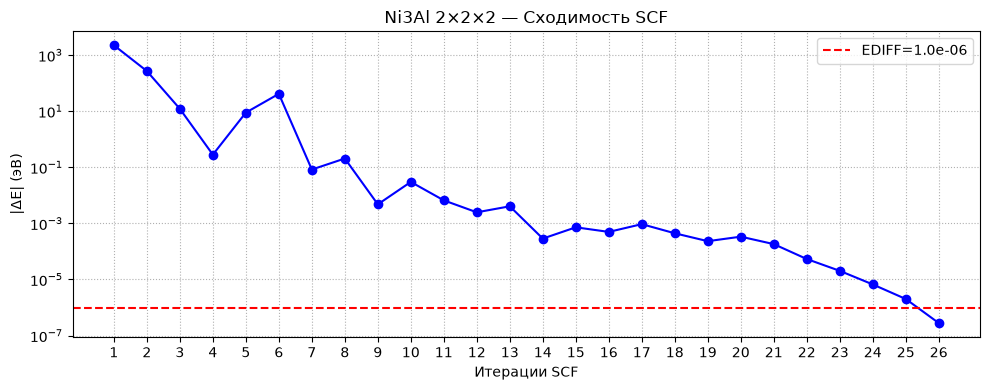

In [80]:
EDIFF_04 = Ni3Al_04_INCAR.get('EDIFF')

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df_04_delta_e['Итерация'], df_04_delta_e['|ΔE| (эВ)'], 'o-', color='b')
ax.axhline(EDIFF_04, color='r', linestyle='--', label=f'EDIFF={EDIFF_04:.1e}')
ax.set_yscale('log')
ax.set_xlabel('Итерации SCF')
ax.set_ylabel('|ΔE| (эВ)')
ax.set_title('Ni3Al 2×2×2 — Сходимость SCF')
ax.grid(linestyle=':')
ax.legend()
max_iter = df_04_delta_e['Итерация'].max()
ax.set_xticks(range(1, max_iter + 1))

plt.tight_layout()
plt.show()

## Ионный цикл

In [81]:
data_04_ion_forces = []
for i, step in enumerate(Ni3Al_04_steps):
    forces = step['forces']
    max_force = max(abs(f) for atom in forces for f in atom)
    data_04_ion_forces.append({'Ионный шаг': i, '|F_max| (эВ/Å)': max_force})

df_04_ion_forces = pd.DataFrame(data_04_ion_forces)
df_04_ion_forces

,Ионный шаг,|F_max| (эВ/Å)
0,0,0.0


> **Примечание по ионной сходимости**     
> Для VASP_run_04 (ISIF=2) был выполнен только начальный SCF-расчёт (шаг 0), релаксация фактически не запускалась (или завершилась сразу, поскольку силы нулевые).

# Кристаллографические парамеры

In [82]:
# [VASP_run_04] Начальный параметр решетки
Ni3Al_04_a = Ni3Al_04_start_structure.lattice.a

# [VASP_run_04] Оптимизированный параметр решетки
Ni3Al_04_a_opt = Ni3Al_04_optimized_structure.lattice.a

# [VASP_run_04] Начальный объем
Ni3Al_04_volume = Ni3Al_04_start_structure.volume

# [VASP_run_04] Оптимизированный объем
Ni3Al_04_volume_opt = Ni3Al_04_optimized_structure.volume

# [VASP_run_04] Пространственная группа
Ni3Al_04_Space_Group = SpacegroupAnalyzer(Ni3Al_04_optimized_structure, 0.1).get_space_group_symbol()

In [83]:
# [VASP_run_02] Начальный параметр решетки
Ni3Al_02_a = Ni3Al_02_start_structure.lattice.a

# [VASP_run_02] Оптимизированный параметр решетки
Ni3Al_02_a_opt = Ni3Al_02_optimized_structure.lattice.a

# [VASP_run_02] Начальный объем
Ni3Al_02_volume = Ni3Al_02_start_structure.volume

# [VASP_run_02] Оптимизированный объем
Ni3Al_02_volume_opt = Ni3Al_02_optimized_structure.volume

# [VASP_run_02] Пространственная группа
Ni3Al_02_Space_Group = SpacegroupAnalyzer(Ni3Al_02_optimized_structure, 0.1).get_space_group_symbol()

In [84]:
pd.set_option('display.float_format', '{:.6f}'.format)

data_crystal_04 = {
    'Система': [
        'Ni3Al (VASP_run_02)',
        'Ni3Al (VASP_run_04)'
    ],
    'Группа': [Ni3Al_02_Space_Group, Ni3Al_04_Space_Group,],
    'a опт. (Å)': [Ni3Al_02_a_opt, Ni3Al_04_a_opt],
    'Δa (%)': [
        (Ni3Al_02_a_opt - Ni3Al_02_a) / Ni3Al_02_a * 100,
        (Ni3Al_04_a_opt - Ni3Al_04_a) / Ni3Al_04_a * 100
    ],
    'V опт. (Å³)': [Ni3Al_02_volume_opt, Ni3Al_04_volume_opt],
    'ΔV (%)': [
        (Ni3Al_02_volume_opt - Ni3Al_02_volume) / Ni3Al_02_volume * 100,
        (Ni3Al_04_volume_opt - Ni3Al_04_volume) / Ni3Al_04_volume * 100
    ],
}

df_crystal_04 = pd.DataFrame(data_crystal_04)
df_crystal_04

,Система,Группа,a опт. (Å),Δa (%),V опт. (Å³),ΔV (%)
0,Ni3Al (VASP_run_02),Pm-3m,7.138090,-0.026748,363.702336,-0.080223
1,Ni3Al (VASP_run_04),Pm-3m,7.140000,0.000000,363.994344,0.000000


## Магнитный момент

In [85]:
Ni3Al_04_total_mag = Ni3Al_04_Outcar.total_mag
Ni3Al_02_total_mag = Ni3Al_02_Outcar.total_mag

print("Ni3Al VASP_run_04:", Ni3Al_04_total_mag, "μ_B")
print("Ni3Al VASP_run_02:", Ni3Al_02_total_mag, "μ_B")

Ni3Al VASP_run_04: -0.0031159 μ_B
Ni3Al VASP_run_02: -0.0018575 μ_B


In [86]:
Ni3Al_04_Outcar.magnetization

({'s': -0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': -0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': -0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': -0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': -0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': -0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': -0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': -0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': -0.0, 'p': -0.0, 'd': -0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': -0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': -0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': -0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': -0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': -0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': -0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': -0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': -0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': -0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': -0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': -0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': -0.0, 'tot': -0

> Все значения равны нулю. Это означает, что на атомах Ni и Al не возникает спонтанной спиновой поляризации – локальные магнитные моменты отсутствуют.
>
> Важно отметить, что сумма локальных моментов не обязана в точности равняться полному моменту, поскольку локальные моменты интегрируются только внутри сфер радиуса `RWIGS`, а часть спиновой плотности может находиться в межатомных областях. Однако в данном случае обе величины практически нулевые, что подтверждает немагнитный характер системы.
>
> Таким образом, добавление `LORBIT = 11` позволило убедиться в отсутствии локальных магнитных моментов в системе Ni₃Al.

P.S. отрицательные нули `-0.0` являются артефактами округления с плавающей точкой

# Полная энергия и энтальпия образования Ni3Al

In [87]:
# Полные энергии
TOTEN_Ni3Al_04 = Ni3Al_04_Outcar.final_energy
TOTEN_Ni3Al_02 = Ni3Al_02_Outcar.final_energy

TOTEN_Ni_01 = Ni_01_Outcar.final_energy
TOTEN_Al_01 = Al_01_Outcar.final_energy

print("Ni3Al VASP_run_04:", TOTEN_Ni3Al_04, "эВ")
print("Ni3Al VASP_run_02:", TOTEN_Ni3Al_02, "эВ")
print("VASP_run_01 Ni:", TOTEN_Ni_01, "эВ")
print("VASP_run_01 Al:", TOTEN_Al_01, "эВ")

Ni3Al VASP_run_04: -177.57531325 эВ
Ni3Al VASP_run_02: -177.57545814 эВ
VASP_run_01 Ni: -22.28985347 эВ
VASP_run_01 Al: -14.98516409 эВ


In [88]:
# Энергия чистых компонентов на одну формульную единицу Ni3Al
E_ref_per_fu = 0.75 * TOTEN_Ni_01 + 0.25 * TOTEN_Al_01

# Энтальпия образования на одну формульную единицу (эВ/ф.е.)
dH_form_ev_per_fu = (TOTEN_Ni3Al_04 - 8 * E_ref_per_fu) / 8

# Перевод в кДж/моль формульных единиц
dH_form_kJ_per_mol_fu = dH_form_ev_per_fu * 96.485

# Перевод в кДж/моль атомов (в ф.е. 4 атома)
dH_form_kJ_per_mol_atom = dH_form_kJ_per_mol_fu / 4

print(dH_form_ev_per_fu, "эВ")
print(dH_form_kJ_per_mol_fu, "кДж/моль формульных единиц")
print(dH_form_kJ_per_mol_atom, "кДж/моль атомов")

-1.7332330312499984 эВ
-167.2309890201561 кДж/моль формульных единиц
-41.807747255039025 кДж/моль атомов


In [89]:
# Энтальпия образования на одну формульную единицу (эВ/ф.е.)
dH_form_ev_per_fu_02 = (TOTEN_Ni3Al_02 - 8 * E_ref_per_fu) / 8

# Перевод в кДж/моль формульных единиц
dH_form_kJ_per_mol_fu_02 = dH_form_ev_per_fu * 96.485

# Перевод в кДж/моль атомов (в ф.е. 4 атома)
dH_form_kJ_per_mol_atom_02 = dH_form_kJ_per_mol_fu / 4

print(dH_form_ev_per_fu_02, "эВ")
print(dH_form_kJ_per_mol_fu_02, "кДж/моль формульных единиц")
print(dH_form_kJ_per_mol_atom_02, "кДж/моль атомов")

-1.7332511424999986 эВ
-167.2309890201561 кДж/моль формульных единиц
-41.807747255039025 кДж/моль атомов


# K-точки

In [90]:
# [VASP_run_04] Кол-во K-точек
Ni3Al_04_N_KPOINTS = len(Ni3Al_04_vasprun.actual_kpoints)

# [VASP_run_04] Координаты первой k-точки по направлению
Ni3Al_04_kx, Ni3Al_04_ky, Ni3Al_04_kz = Ni3Al_04_vasprun.kpoints.kpts[0]

# [VASP_run_04] K-cетка
Ni3Al_04_kmesh = f"{int(Ni3Al_04_kx)}×{int(Ni3Al_04_ky)}×{int(Ni3Al_04_kz)}"

# Приводим к примитивной ячейке для корректного получения точек высокой симметрии (зона Бриллюэна задана для примитивной ячейки)
prim_04 = SpacegroupAnalyzer(Ni3Al_04_optimized_structure).get_primitive_standard_structure()

# [VASP_run_04] K-точки высокой симметрии
Ni3Al_04_hs_points = ', '.join(HighSymmKpath(prim_04).kpath['kpoints'].keys())

In [91]:
# [VASP_run_02] Кол-во K-точек
Ni3Al_02_N_KPOINTS = len(Ni3Al_02_vasprun.actual_kpoints)

# [VASP_run_02] Координаты первой k-точки по направлению
Ni3Al_02_kx, Ni3Al_02_ky, Ni3Al_02_kz = Ni3Al_02_vasprun.kpoints.kpts[0]

# [VASP_run_02] K-cетка
Ni3Al_02_kmesh = f"{Ni3Al_02_kx}×{Ni3Al_02_ky}×{Ni3Al_02_kz}"

# Приводим к примитивной ячейке для корректного получения точек высокой симметрии (зона Бриллюэна задана для примитивной ячейки)
prim_02 = SpacegroupAnalyzer(Ni3Al_02_optimized_structure).get_primitive_standard_structure()

# [VASP_run_02] K-точки высокой симметрии
Ni3Al_02_hs_points = ', '.join(HighSymmKpath(prim_02).kpath['kpoints'].keys())

In [92]:
data_kpoints_04 = {
    'Система': ['Ni3Al (VASP_run_04)', 'Ni3Al (VASP_run_02)'],
    'N k-точек': [Ni3Al_04_N_KPOINTS, Ni3Al_02_N_KPOINTS],
    'K-сетка': [Ni3Al_04_kmesh , Ni3Al_02_kmesh,],
    'Высокосимм. точки': [Ni3Al_02_hs_points, Ni3Al_02_hs_points,],
}

df_kpoints_04 = pd.DataFrame(data_kpoints_04)
df_kpoints_04

,Система,N k-точек,K-сетка,Высокосимм. точки
0,Ni3Al (VASP_run_04),35,8×8×8,"\Gamma, X, R, M"
1,Ni3Al (VASP_run_02),35,8×8×8,"\Gamma, X, R, M"


# Плотность состояний (DOS)

In [93]:
# [VASP_run_04] Полная DOS (объект CompleteDos)
Ni3Al_04_complete_dos = Ni3Al_04_vasprun.complete_dos

# [VASP_run_04] Энергетическая сетка для DOS (эВ)
Ni3Al_04_complete_dos_energy = Ni3Al_04_complete_dos.energies

# [VASP_run_04] Суммарная плотность состояний (states/eV)
Ni3Al_04_complete_dos_densities = sum(Ni3Al_04_complete_dos.densities.values())

# [VASP_run_04] Уровень Ферми (эВ)
Ni3Al_04_efermi = Ni3Al_04_Outcar.efermi

In [94]:
# [VASP_run_02] Полная DOS (объект CompleteDos)
Ni3Al_02_complete_dos = Ni3Al_02_vasprun.complete_dos

# [VASP_run_02] Энергетическая сетка для DOS (эВ)
Ni3Al_02_complete_dos_energy = Ni3Al_02_complete_dos.energies

# [VASP_run_02] Суммарная плотность состояний (states/eV)
Ni3Al_02_complete_dos_densities = sum(Ni3Al_02_complete_dos.densities.values())

# [VASP_run_02] Уровень Ферми (эВ)
Ni3Al_02_efermi = Ni3Al_02_Outcar.efermi

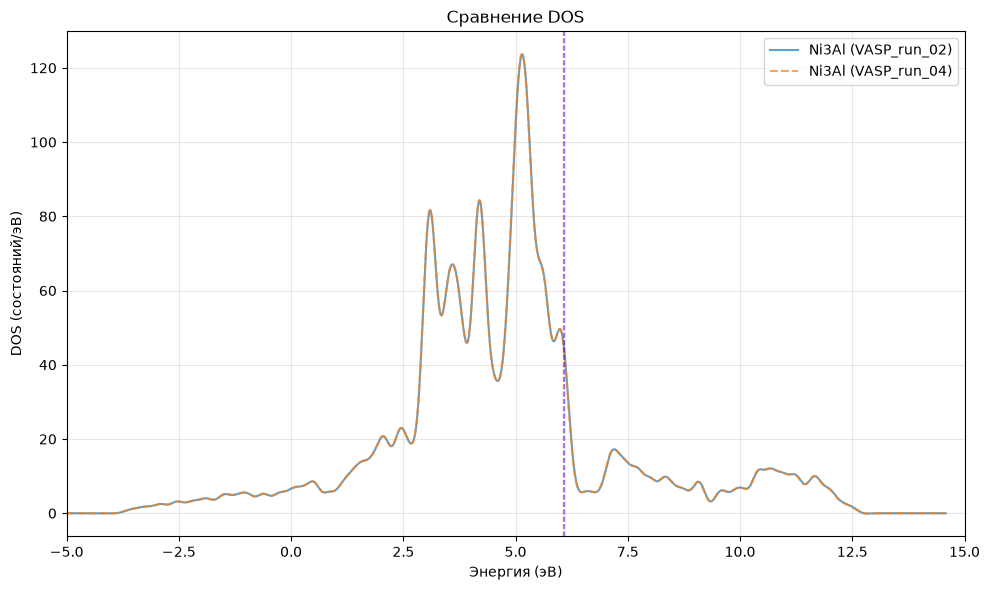

In [99]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

axes.plot(Ni3Al_02_complete_dos_energy, Ni3Al_02_complete_dos_densities, label='Ni3Al (VASP_run_02)', alpha=0.7)
axes.plot(Ni3Al_04_complete_dos_energy, Ni3Al_04_complete_dos_densities, label='Ni3Al (VASP_run_04)', alpha=0.7, linestyle='--',)
axes.axvline(Ni3Al_02_efermi, color='blue', linestyle='--', alpha=0.5, linewidth=1)
axes.axvline(Ni3Al_04_efermi, color='red', linestyle='--', alpha=0.5, linewidth=1)
axes.set_xlabel('Энергия (эВ)')
axes.set_ylabel('DOS (состояний/эВ)')
axes.set_title('Сравнение DOS')
axes.grid(alpha=0.3)
axes.legend()


plt.xlim(-5, 15)
plt.tight_layout()
plt.show()

## Проектированный DOS (LORBIT=11)

In [96]:
# Извлекаем проектированную DOS по элементам и получаем список элементов
Ni3Al_04_pdos_element_dos = Ni3Al_04_complete_dos.get_element_dos()
Ni3Al_04_elements = list(Ni3Al_04_pdos_element_dos.keys())

# PDOS для Al и Ni
Ni3Al_04_pdos_Al = Ni3Al_04_pdos_element_dos[Ni3Al_04_elements[0]]
Ni3Al_04_pdos_Ni = Ni3Al_04_pdos_element_dos[Ni3Al_04_elements[1]]

# Спиновые компоненты плотностей состояний
dens_up_total = Ni3Al_04_complete_dos.get_densities(Spin.up)
dens_down_total = Ni3Al_04_complete_dos.get_densities(Spin.down)

dens_up_Al = Ni3Al_04_pdos_Al.get_densities(Spin.up)
dens_down_Al = Ni3Al_04_pdos_Al.get_densities(Spin.down)

dens_up_Ni = Ni3Al_04_pdos_Ni.get_densities(Spin.up)
dens_down_Ni = Ni3Al_04_pdos_Ni.get_densities(Spin.down)


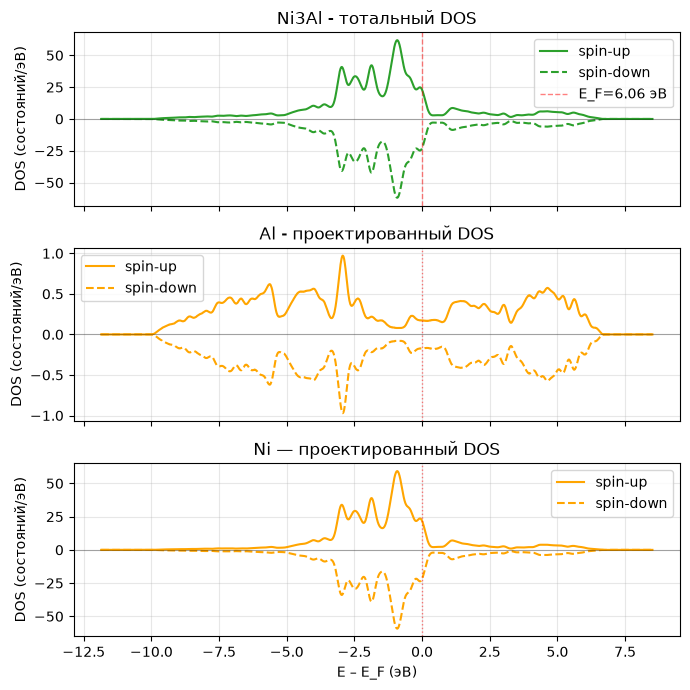

In [97]:
# Сдвиг энергии относительно уровня Ферми
e_total = Ni3Al_04_complete_dos_energy - Ni3Al_04_efermi
e_al = Ni3Al_04_pdos_Al.energies - Ni3Al_04_efermi
e_ni = Ni3Al_04_pdos_Ni.energies - Ni3Al_04_efermi

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

# Ni3Al
axes[0].plot(e_total, dens_up_total, '-', label='spin-up', color='tab:green', linewidth=1.5)
axes[0].plot(e_total, -dens_down_total, '--', label='spin-down', color='tab:green', linewidth=1.5)
axes[0].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[0].axvline(0, color='r', linestyle='--', alpha=0.5, linewidth=1, label=f'E_F={Ni3Al_04_efermi:.2f} эВ')
axes[0].set_ylabel('DOS (состояний/эВ)')
axes[0].set_title('Ni3Al - тотальный DOS')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Al
axes[1].plot(e_al, dens_up_Al, '-', label='spin-up', color='orange', linewidth=1.5)
axes[1].plot(e_al, -dens_down_Al, '--', label='spin-down', color='orange', linewidth=1.5)
axes[1].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[1].axvline(0, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[1].set_ylabel('DOS (состояний/эВ)')
axes[1].set_title('Al - проектированный DOS')
axes[1].grid(alpha=0.3)
axes[1].legend()

# Ni
axes[2].plot(e_ni, dens_up_Ni, '-', label='spin-up', color='orange', linewidth=1.5)
axes[2].plot(e_ni, -dens_down_Ni, '--', label='spin-down', color='orange', linewidth=1.5)
axes[2].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[2].axvline(0, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[2].set_xlabel('E – E_F (эВ)')
axes[2].set_ylabel('DOS (состояний/эВ)')
axes[2].set_title('Ni — проектированный DOS')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# Сводная таблица

In [98]:
df_run2 = pd.DataFrame([
    {'Система': 'Ni3Al (VASP_run_04)', 'Полная энергия (эВ)': TOTEN_Ni3Al_04, 'E_F (эВ)': Ni3Al_04_efermi, 'Магн. момент (μB)': Ni3Al_04_total_mag, 'ΔH_обр (кДж/моль атомов)': dH_form_kJ_per_mol_atom},
    {'Система': 'Ni3Al (VASP_run_02)', 'Полная энергия (эВ)': TOTEN_Ni3Al_02, 'E_F (эВ)': Ni3Al_02_efermi, 'Магн. момент (μB)': Ni3Al_02_total_mag, 'ΔH_обр (кДж/моль атомов)': dH_form_kJ_per_mol_atom_02},
])

df_run2 = df_run2.merge(df_crystal_04)
df_run2 = df_run2.merge(df_kpoints_04)
df_run2

,Система,Полная энергия (эВ),E_F (эВ),Магн. момент (μB),ΔH_обр (кДж/моль атомов),Группа,a опт. (Å),Δa (%),V опт. (Å³),ΔV (%),N k-точек,K-сетка,Высокосимм. точки
0,Ni3Al (VASP_run_04),-177.575313,6.062800,-0.003116,-41.807747,Pm-3m,7.140000,0.000000,363.994344,0.000000,35,8×8×8,"\Gamma, X, R, M"
1,Ni3Al (VASP_run_02),-177.575458,6.071000,-0.001857,-41.807747,Pm-3m,7.138090,-0.026748,363.702336,-0.080223,35,8×8×8,"\Gamma, X, R, M"
